This notebook just takes the output csv and .npy files generated during training and visualizes the results. It does not run inference

In [1]:
# In your first cell, turn on the ipympl interactive backend:
%matplotlib widget
import matplotlib.pyplot as plt

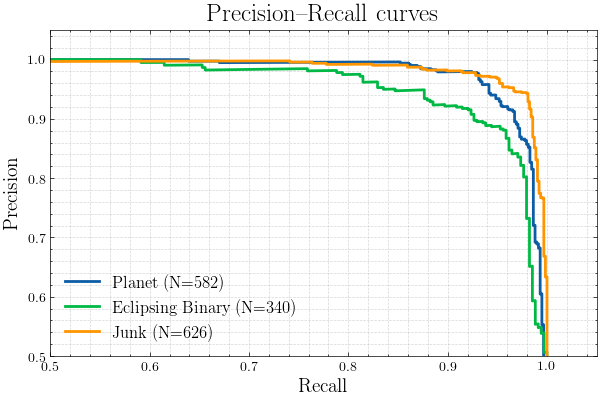

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
import scienceplots

plt.style.use('science')
# If you want widget‐based clicks in a Jupyter environment, uncomment:
# %matplotlib widget

# ─── 0) load & preprocess ────────────────────────────────────────────────
training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250502/" \
                      "cshallue/AstroCNNModelVetting_cshallue_20250502_000812"
test_labels = np.load(f"{training_run_folder}/evaluation/test_label.npy")  # (1548,4)
test_pred   = np.load(f"{training_run_folder}/evaluation/test_pred.npy")

# drop the “Not Sure” column
test_labels = np.delete(test_labels, 2, axis=1)
test_pred   = np.delete(test_pred,   2, axis=1)

label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = test_labels.sum(axis=0).astype(int)

# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(label_names)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ─── 2) plot all three curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)

ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)

# ─── 3) add interactive annotation ───────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0,0), xytext=(-40,-20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->")
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    annot.xy = (d["recall"][idx], d["precision"][idx])
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {d['precision'][idx]:.3f}\n"
        f"Recall = {d['recall'][idx]:.3f}\n"
        f"Threshold = {d['thresholds'][idx]:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

# ─── 4) legend & show ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 5) extra diagnostics (optional) ────────────────────────────────────
# You can still compute confusion matrices, ROC, etc., exactly as before.


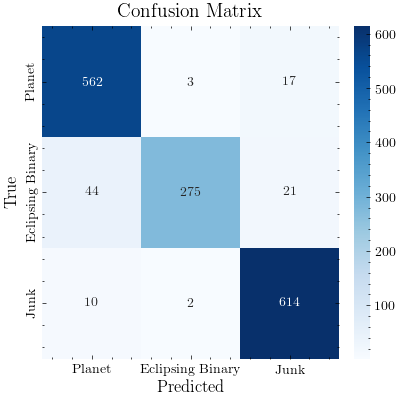

,precision,recall,f1-score,support
Planet,0.912000,0.966000,0.938000,582.000000
Eclipsing Binary,0.982000,0.809000,0.887000,340.000000
Junk,0.942000,0.981000,0.961000,626.000000
accuracy,0.937000,0.937000,0.937000,0.937000
macro avg,0.945000,0.918000,0.929000,1548.000000
weighted avg,0.940000,0.937000,0.936000,1548.000000


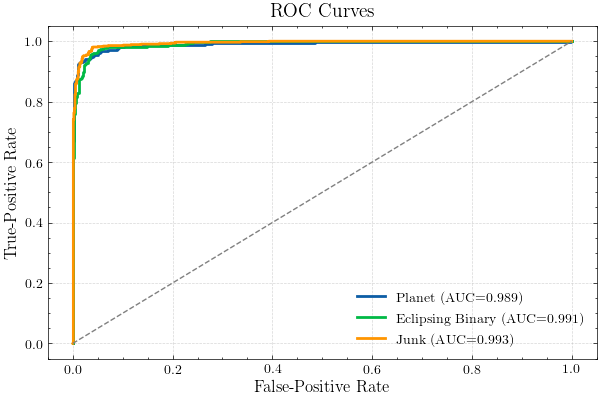

In [3]:
# ─── Cell 2: More Diagnostics ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

# 1) Confusion matrix heatmap
y_true = test_labels.argmax(axis=1)
y_pred = test_pred.argmax(axis=1)



cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title("Confusion Matrix", fontsize=14)
plt.show()

# 2) Styled classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).T.round(3)

# pick only the float‐valued metric columns
num_cols = df_report.select_dtypes(include=['float']).columns

styled = (
    df_report.style
      .background_gradient(cmap="Blues", subset=pd.IndexSlice[:, num_cols])
      .set_caption("Classification Report")
)
display(styled)

# 3) ROC curves + AUC
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)
for i, name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_pred[:, i])
    auc = roc_auc_score(test_labels[:, i], test_pred[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1], [0,1], "--", color="gray", lw=1)
ax.set_xlabel("False-Positive Rate", fontsize=12)
ax.set_ylabel("True-Positive Rate",  fontsize=12)
ax.set_title("ROC Curves",            fontsize=14)
ax.legend(loc="lower right", fontsize=10, framealpha=0.8)
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


---

## Prediction Visualizer for the case of cross-validation

In [4]:
# In your first cell, turn on the ipympl interactive backend:
%matplotlib widget

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
import scienceplots

# 0 - Load and preprocess
# crossval_training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250520-1546/cshallue-cv"
crossval_training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250522-1615/pablomer-cv"
number_of_folds = 2

for i in range(number_of_folds):
    print(i)


0
1


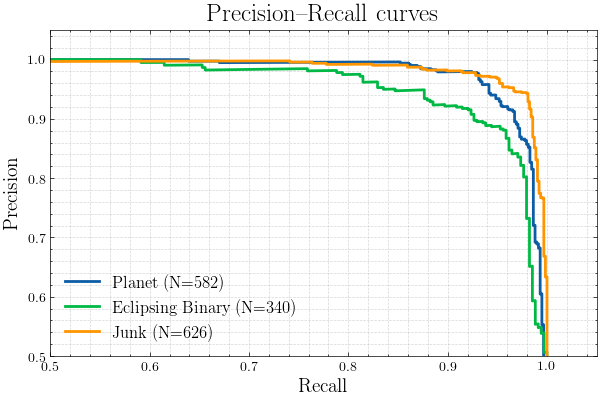

In [9]:

plt.style.use('science')
# If you want widget‐based clicks in a Jupyter environment, uncomment:
# %matplotlib widget

# ─── 0) load & preprocess ────────────────────────────────────────────────
training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250502/" \
                      "cshallue/AstroCNNModelVetting_cshallue_20250502_000812"
test_labels = np.load(f"{training_run_folder}/evaluation/test_label.npy")  # (1548,4)
test_pred   = np.load(f"{training_run_folder}/evaluation/test_pred.npy")

# drop the “Not Sure” column
test_labels = np.delete(test_labels, 2, axis=1)
test_pred   = np.delete(test_pred,   2, axis=1)

label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = test_labels.sum(axis=0).astype(int)

# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(label_names)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ─── 2) plot all three curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)

ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)

# ─── 3) add interactive annotation ───────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0,0), xytext=(-40,-20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->")
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    annot.xy = (d["recall"][idx], d["precision"][idx])
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {d['precision'][idx]:.3f}\n"
        f"Recall = {d['recall'][idx]:.3f}\n"
        f"Threshold = {d['thresholds'][idx]:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

# ─── 4) legend & show ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 5) extra diagnostics (optional) ────────────────────────────────────
# You can still compute confusion matrices, ROC, etc., exactly as before.


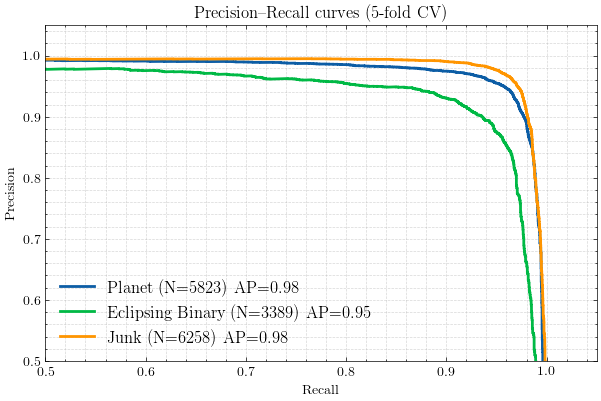

Aggregated exodash table: 15470 rows × 7 cols
   astro_id  model_no    disp_p    disp_e    disp_n    disp_j true_label
0      3083         1  0.066332  0.917412  0.001362  0.014894          e
1      3089         1  0.923843  0.051268  0.000977  0.023912          p
2      3109         1  0.003905  0.890300  0.001592  0.104203          e
3      3112         1  0.002862  0.908750  0.001347  0.087041          e
4      3113         1  0.013304  0.975606  0.001075  0.010015          e


In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)
# import scienceplots
# plt.style.use('science')
# %matplotlib widget   # if you want interactive

# ─── 0) locate & load all folds ────────────────────────────────────────────
cv_root   = "/pdo/users/pablomer/mnt/tess/models/vetting/20250522-1615/pablomer-cv"
fold_dirs = sorted(glob.glob(os.path.join(cv_root, "fold*")))

labels_list = []
preds_list  = []
csv_list    = []    # ← collect each fold's exodash CSV

for fold in fold_dirs:
    # ─── find the evaluation/ dir ─────────────────────────────────────────
    eval_dirs = glob.glob(os.path.join(fold, "**", "evaluation"), recursive=True)
    if not eval_dirs:
        raise RuntimeError(f"no evaluation dir found under {fold!r}")
    eval_dir = eval_dirs[0]

    # ─── load val labels & preds ───────────────────────────────────────────
    lab  = np.load(os.path.join(eval_dir, "val_label.npy"))
    pred = np.load(os.path.join(eval_dir, "val_pred.npy"))
    labels_list.append(lab)
    preds_list.append(pred)

    # ─── find & read that fold’s exodash CSV ───────────────────────────────
    csv_paths = glob.glob(os.path.join(fold, "**", "val_exodash_results.csv"), recursive=True)
    if not csv_paths:
        raise RuntimeError(f"no val_exodash_results.csv found under {fold!r}")
    csv_path = csv_paths[0]
    df      = pd.read_csv(csv_path)
    csv_list.append(df)

# ─── aggregate everything ─────────────────────────────────────────────────
# stack labels & preds
all_labels = np.vstack(labels_list)
all_preds  = np.vstack(preds_list)

# drop the “Not Sure” column (index 2)
all_labels = np.delete(all_labels, 2, axis=1)
all_preds  = np.delete(all_preds,  2, axis=1)

# stack CSVs
all_exodash = pd.concat(csv_list, ignore_index=True)

# ─── now do your PR-curve plotting exactly as before ─────────────────────
label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = all_labels.sum(axis=0).astype(int)

pr_data = []
for i, name in enumerate(label_names):
    y_true  = all_labels[:, i]
    y_score = all_preds[:,  i]
    p, r, t = precision_recall_curve(y_true, y_score)
    ap      = average_precision_score(y_true, y_score)
    pr_data.append(dict(precision=p, recall=r, thresholds=t, ap=ap))

fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)
for i, name in enumerate(label_names):
    d   = pr_data[i]
    lbl = f"{name} (N={counts[i]})  AP={d['ap']:.2f}"
    ax.plot(d["recall"][:-1], d["precision"][:-1], lw=2, label=lbl)

ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision–Recall curves (5-fold CV)")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)

plt.show()

# ─── finally, if you want to inspect the combined exodash results: ───────
print(f"Aggregated exodash table: {all_exodash.shape[0]} rows × {all_exodash.shape[1]} cols")
# e.g. display first few rows
print(all_exodash.head())

# Save the csv
all_exodash.to_csv("exodash_5folds.csv", index=False)


In [8]:
import os
os.getcwd()

'/pdo/users/pablomer'

---

# Running this on a new model

Student head:


,astro_id,model_no,disp_p,disp_e,disp_n,disp_j,true_label
0,3581,1,1.324241e-04,9.987913e-01,0.000027,0.001049,e
1,14131,1,7.865285e-11,2.798724e-08,0.000015,0.999985,j
2,12209,1,1.957272e-05,1.169884e-04,0.000022,0.999841,j
3,1395,1,1.425196e-04,9.970029e-01,0.000032,0.002823,e
4,38089,1,2.316328e-06,3.863036e-05,0.000025,0.999934,j


Ensemble head:


,astro_id,true_j,true_n,true_e,true_p,disp_p_1,disp_e_1,disp_n_1,disp_j_1,disp_p_2,...,disp_j_8,disp_p_9,disp_e_9,disp_n_9,disp_j_9,disp_p_10,disp_e_10,disp_n_10,disp_j_10,true_label
0,3581,0,0,1,0,0.001033,0.990689,0.002186,0.006091,0.037230,...,0.007957,0.131352,0.847204,0.012443,0.009002,0.001784,0.992121,0.003285,0.002810,e
1,14131,1,0,0,0,0.000006,0.000841,0.003061,0.996092,0.000013,...,0.996201,0.000006,0.000327,0.001448,0.998219,0.000001,0.000178,0.003141,0.996680,j
2,12209,1,0,0,0,0.000036,0.004733,0.006307,0.988925,0.000106,...,0.989116,0.000400,0.010873,0.005911,0.982816,0.000088,0.001890,0.008707,0.989315,j
3,1395,0,0,1,0,0.001132,0.978524,0.003201,0.017142,0.054235,...,0.075866,0.140481,0.820124,0.014434,0.024961,0.022509,0.952099,0.007806,0.017586,e
4,38089,1,0,0,0,0.000130,0.002290,0.004202,0.993378,0.000145,...,0.994425,0.002331,0.009759,0.006540,0.981370,0.000096,0.000908,0.007935,0.991061,j



Comparing PR curves for class 'p'
Merged rows: 1548 (student: 1548, ensemble: 1548)


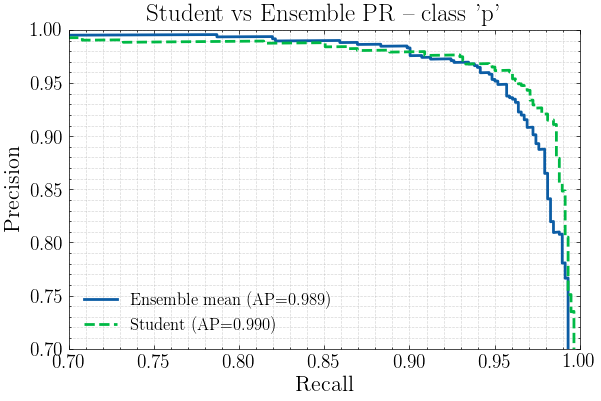

Ensemble mean AP: 0.9887
Student       AP: 0.9903
Individual ensemble member APs:
  Model 1: 0.9683
  Model 2: 0.9796
  Model 3: 0.9726
  Model 4: 0.9755
  Model 5: 0.9737
  Model 6: 0.9700
  Model 7: 0.9703
  Model 8: 0.9737
  Model 9: 0.9822
  Model 10: 0.9799


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import scienceplots

plt.style.use("science")

# ─── 0) paths / config ───────────────────────────────────────────────────
# Set this to the class you want to plot, e.g. "P", "E", "J", etc.
TARGET_CLASS = "p"

# distilled_dir = '/pdo/astronet-data/models/vetting/experimental/pablomer/oct2025_30minbin_v2/20251110/student-2k-pretrained/AstroCNNModelVetting_pablomer_student_20251110_165749/evaluation/test_exodash_results.csv'
distilled_dir = '/pdo/astronet-data/models/vetting/experimental/pablomer/oct2025_cadencebin/20251111/student-2k-nopretrained/AstroCNNModelVetting_pablomer_student_20251111_123622/evaluation/test_exodash_results.csv'
original_ensemble_dir = '/pdo/astronet-data/models/vetting/experimental/pablomer/oct2025_cadencebin/20251028/pablomer-2k-nopretrained/all_preds.csv'

distilled_df = pd.read_csv(distilled_dir)
original_ensemble_df = pd.read_csv(original_ensemble_dir)

print("Student head:")
display(distilled_df.head())
print("Ensemble head:")
display(original_ensemble_df.head())

print(f"\nComparing PR curves for class '{TARGET_CLASS}'")

# ─── 1) clean & merge ────────────────────────────────────────────────────
dist_clean = distilled_df.dropna(axis=0).reset_index(drop=True)
ens_clean  = original_ensemble_df.dropna(axis=0).reset_index(drop=True)

merged = pd.merge(
    dist_clean,
    ens_clean,
    on="astro_id",
    how="inner",
    suffixes=("_student", "_ens")
)

print(
    f"Merged rows: {len(merged)} "
    f"(student: {len(distilled_df)}, ensemble: {len(original_ensemble_df)})"
)

# labels (one-vs-rest for TARGET_CLASS)
if "true_label_student" in merged.columns and "true_label_ens" in merged.columns:
    mismatch = (merged["true_label_student"] != merged["true_label_ens"]).sum()
    if mismatch:
        print(f"WARNING: {mismatch} rows have different labels between student and ensemble.")
    label_col = "true_label_ens"
elif "true_label" in merged.columns:
    label_col = "true_label"
else:
    raise ValueError("Couldn't find a true_label column after merging.")

y_true = (merged[label_col].astype(str) == TARGET_CLASS).astype(int).values

# ─── 2) get student + ensemble scores ────────────────────────────────────
# student
student_col = f"disp_{TARGET_CLASS}"
if student_col not in merged.columns:
    raise ValueError(f"Expected student column '{student_col}' not found in merged dataframe.")
student_scores = merged[student_col].values

# ensemble members (disp_CLASS_1 ... disp_CLASS_10)
ens_score_cols = [f"disp_{TARGET_CLASS}_{i}" for i in range(1, 11)]
missing = [c for c in ens_score_cols if c not in merged.columns]
if missing:
    raise ValueError(f"Missing ensemble columns for class '{TARGET_CLASS}': {missing}")

scores_ens = merged[ens_score_cols].values      # shape (N, 10)
ensemble_scores = scores_ens.mean(axis=1)       # mean across 10 models

# ─── 3) compute PR curves ────────────────────────────────────────────────
# ensemble mean
prec_ens, rec_ens, thr_ens = precision_recall_curve(y_true, ensemble_scores)
ap_ens = average_precision_score(y_true, ensemble_scores)

# student
prec_student, rec_student, thr_student = precision_recall_curve(y_true, student_scores)
ap_student = average_precision_score(y_true, student_scores)

# (optional) per-member APs – still printed like in your original code
ensemble_member_aps = []
for i in range(scores_ens.shape[1]):
    ap_i = average_precision_score(y_true, scores_ens[:, i])
    ensemble_member_aps.append(ap_i)

# ─── 4) prepare data for interactive plotting ────────────────────────────
# match the structure of your PR–interactive notebook
label_names = [
    f"Ensemble mean (AP={ap_ens:.3f})",
    f"Student (AP={ap_student:.3f})",
]
pr_data = [
    {
        "precision": prec_ens,
        "recall":    rec_ens,
        "thresholds":thr_ens,
    },
    {
        "precision": prec_student,
        "recall":    rec_student,
        "thresholds":thr_student,
    },
]

# ─── 5) plot with science style + interactive annotation ────────────────
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    d = pr_data[i]
    # thresholds has length len(precision) - 1, so slice off last point
    ln, = ax.plot(
        d["recall"][:-1],
        d["precision"][:-1],
        lw=2,
        linestyle="-" if i == 0 else "--",  # solid for ensemble, dashed for student
        label=name,
    )
    lines.append(ln)

ax.set_xlabel("Recall", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)
ax.set_title(f"Student vs Ensemble PR – class '{TARGET_CLASS}'", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.7, 1.0)
ax.set_ylim(0.7, 1.0)
ax.tick_params(axis="both", which="major", labelsize=14)

# ─── 6) interactive annotation on click ─────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0, 0), xytext=(-40, -20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->"),
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    r   = d["recall"][idx]
    p   = d["precision"][idx]
    # thresholds has length len(p) - 1, so guard the last index
    if idx >= len(d["thresholds"]):
        thr = d["thresholds"][-1]
    else:
        thr = d["thresholds"][idx]

    annot.xy = (r, p)
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {p:.3f}\n"
        f"Recall    = {r:.3f}\n"
        f"Threshold = {thr:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    # look for the nearest line that was clicked
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 7) summary printout ────────────────────────────────────────────────
print(f"Ensemble mean AP: {ap_ens:.4f}")
print(f"Student       AP: {ap_student:.4f}")
print("Individual ensemble member APs:")
for i, ap_i in enumerate(ensemble_member_aps, start=1):
    print(f"  Model {i}: {ap_i:.4f}")

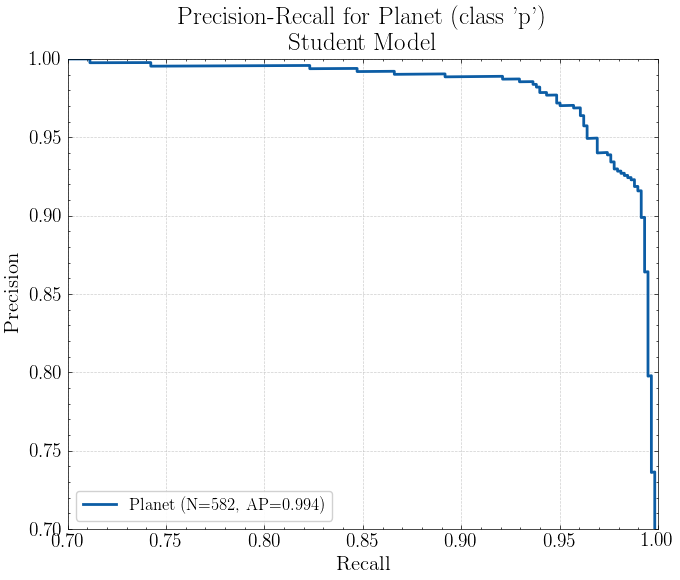

Results for /pdo/astronet-data/models/vetting/experimental/pablomer/oct2025_30minbin/20251104/pablomer-2k-pretrained/all_preds.csv
Planet             (N= 582) : AP = 0.9938


In [12]:
# %%
# --- Precision–Recall for PLANET class from a single 10-model ensemble run (with onclick) ---

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

CSV_PATH = "/pdo/astronet-data/models/vetting/experimental/pablomer/oct2025_30minbin/20251104/pablomer-2k-pretrained/all_preds.csv"

TARGET_CLASS = 'p'   # planet
CLASS_NAME   = 'Planet'

DROP_NA = True
SPLIT_FILTER = None   # e.g. ('split', '==', 'test')


def _load_y_true_and_ensemble_scores(csv_path, target_class, drop_na=True, split_filter=None):
    """
    For a given target_class (e.g. 'p'), load:
      - y_true:  0/1 labels (one-vs-rest for that class)
      - ensemble_scores: mean over disp_{target_class}_1..10
    """
    df_local = pd.read_csv(csv_path)
    if drop_na:
        df_local = df_local.dropna(axis=0).reset_index(drop=True)

    if split_filter is not None:
        col, op, val = split_filter
        if op == '==':
            df_local = df_local[df_local[col] == val].reset_index(drop=True)
        elif op == '!=':
            df_local = df_local[df_local[col] != val].reset_index(drop=True)
        else:
            raise ValueError("Unsupported operator in SPLIT_FILTER. Use '==' or '!='.")

    # --- y_true: one-vs-rest for this class ---
    if 'true_label' in df_local.columns:
        y_true_local = (
            df_local['true_label'].astype(str).str.lower() == target_class.lower()
        ).astype(int).values
    else:
        one_hot_col = f"true_{target_class}"
        if one_hot_col not in df_local.columns:
            raise ValueError(
                f"Missing 'true_label' and one-hot column '{one_hot_col}' in {csv_path}"
            )
        y_true_local = df_local[one_hot_col].astype(int).values

    # --- Ensemble scores = mean over disp_{class}_{1..10} ---
    score_cols = [f"disp_{target_class}_{i}" for i in range(1, 11)]
    missing = [c for c in score_cols if c not in df_local.columns]
    if missing:
        raise ValueError(
            f"Missing expected columns for target class '{target_class}' in {csv_path}: {missing}"
        )

    ensemble_scores_local = df_local[score_cols].values.mean(axis=1)
    return y_true_local, ensemble_scores_local


# ─── Compute PR curve for planet ─────────────────────────────────────────
y_true, scores = _load_y_true_and_ensemble_scores(
    CSV_PATH, TARGET_CLASS, drop_na=DROP_NA, split_filter=SPLIT_FILTER
)
prec, rec, thr = precision_recall_curve(y_true, scores)
ap = average_precision_score(y_true, scores)
N_pos = int(y_true.sum())

# ─── Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

# slice off the last point to match thresholds length
(line,) = ax.plot(
    rec[:-1],
    prec[:-1],
    linewidth=2.0,
    label=f"{CLASS_NAME} (N={N_pos}, AP={ap:.3f})",
)

ax.set_xlabel("Recall", fontsize=15)
ax.set_ylabel("Precision", fontsize=15)
ax.set_title(
    f"Precision-Recall for {CLASS_NAME} (class '{TARGET_CLASS}') \n Student Model",
    fontsize=18,
)
ax.set_xlim(0.7, 1.0)
ax.set_ylim(0.7, 1.0)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(loc="lower left", frameon=True, framealpha=0.9, fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=14)

plt.tight_layout()

# ─── On-click annotation ─────────────────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0, 0),
    xytext=(-40, -20),
    textcoords="offset points",
    ha="right",
    va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->"),
)
annot.set_visible(False)


def update_annot(ind):
    idx = ind["ind"][0]
    r = rec[idx]
    p = prec[idx]
    # thresholds has length len(prec) - 1
    if idx >= len(thr):
        t = thr[-1]
    else:
        t = thr[idx]

    annot.xy = (r, p)
    annot.set_text(
        f"{CLASS_NAME}\n"
        f"Precision = {p:.3f}\n"
        f"Recall    = {r:.3f}\n"
        f"Threshold = {t:.3f}"
    )
    annot.set_fontsize(12)


def onclick(event):
    if event.inaxes != ax:
        return
    hit, ind = line.contains(event)
    if hit:
        update_annot(ind)
        annot.set_visible(True)
        fig.canvas.draw_idle()
    elif annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()


fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()

# ─── Print summary ───────────────────────────────────────────────────────
print(f"Results for {CSV_PATH}")
print(f"{CLASS_NAME:18s} (N={N_pos:4d}) : AP = {ap:.4f}")